In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_excel("glass.xlsx", sheet_name="glass")

print("Shape:", df.shape)
print("\nData Types:\n", df.dtypes)
print("\nSummary Statistics:\n", df.describe())
print("\nClass Distribution (Type):\n", df['Type'].value_counts().sort_index())
print("\nMissing Values:\n", df.isnull().sum())
print("\nDuplicate Rows:", df.duplicated().sum())

Shape: (214, 10)

Data Types:
 RI      float64
Na      float64
Mg      float64
Al      float64
Si      float64
K       float64
Ca      float64
Ba      float64
Fe      float64
Type      int64
dtype: object

Summary Statistics:
                RI          Na          Mg          Al          Si           K  \
count  214.000000  214.000000  214.000000  214.000000  214.000000  214.000000   
mean     1.518365   13.407850    2.684533    1.444907   72.650935    0.497056   
std      0.003037    0.816604    1.442408    0.499270    0.774546    0.652192   
min      1.511150   10.730000    0.000000    0.290000   69.810000    0.000000   
25%      1.516522   12.907500    2.115000    1.190000   72.280000    0.122500   
50%      1.517680   13.300000    3.480000    1.360000   72.790000    0.555000   
75%      1.519157   13.825000    3.600000    1.630000   73.087500    0.610000   
max      1.533930   17.380000    4.490000    3.500000   75.410000    6.210000   

               Ca          Ba          Fe  

In [2]:
# Check for inconsistencies
print("Unique Type values:", sorted(df['Type'].unique()))
print("\nNegative values check:")
print((df.drop(columns='Type') < 0).sum())

Unique Type values: [1, 2, 3, 5, 6, 7]

Negative values check:
RI    0
Na    0
Mg    0
Al    0
Si    0
K     0
Ca    0
Ba    0
Fe    0
dtype: int64


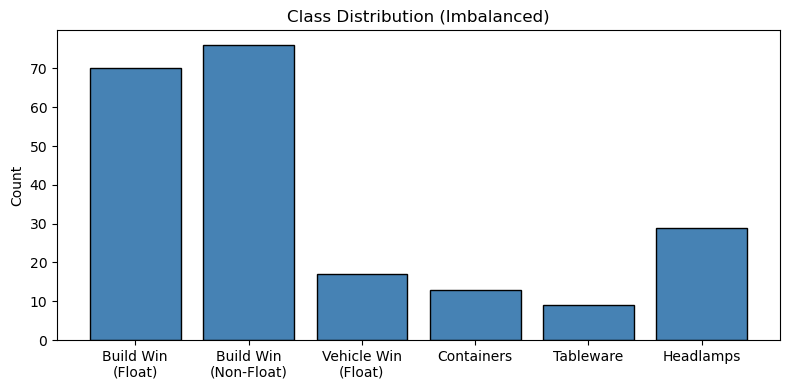

In [3]:
# ── Class Distribution ────────────────────────────────────────────
type_labels = {1: 'Build Win\n(Float)', 2: 'Build Win\n(Non-Float)',
               3: 'Vehicle Win\n(Float)', 5: 'Containers',
               6: 'Tableware', 7: 'Headlamps'}

counts = df['Type'].value_counts().sort_index()
plt.figure(figsize=(8, 4))
plt.bar([type_labels.get(int(t), str(t)) for t in counts.index],
        counts.values, color='steelblue', edgecolor='black')
plt.title('Class Distribution (Imbalanced)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

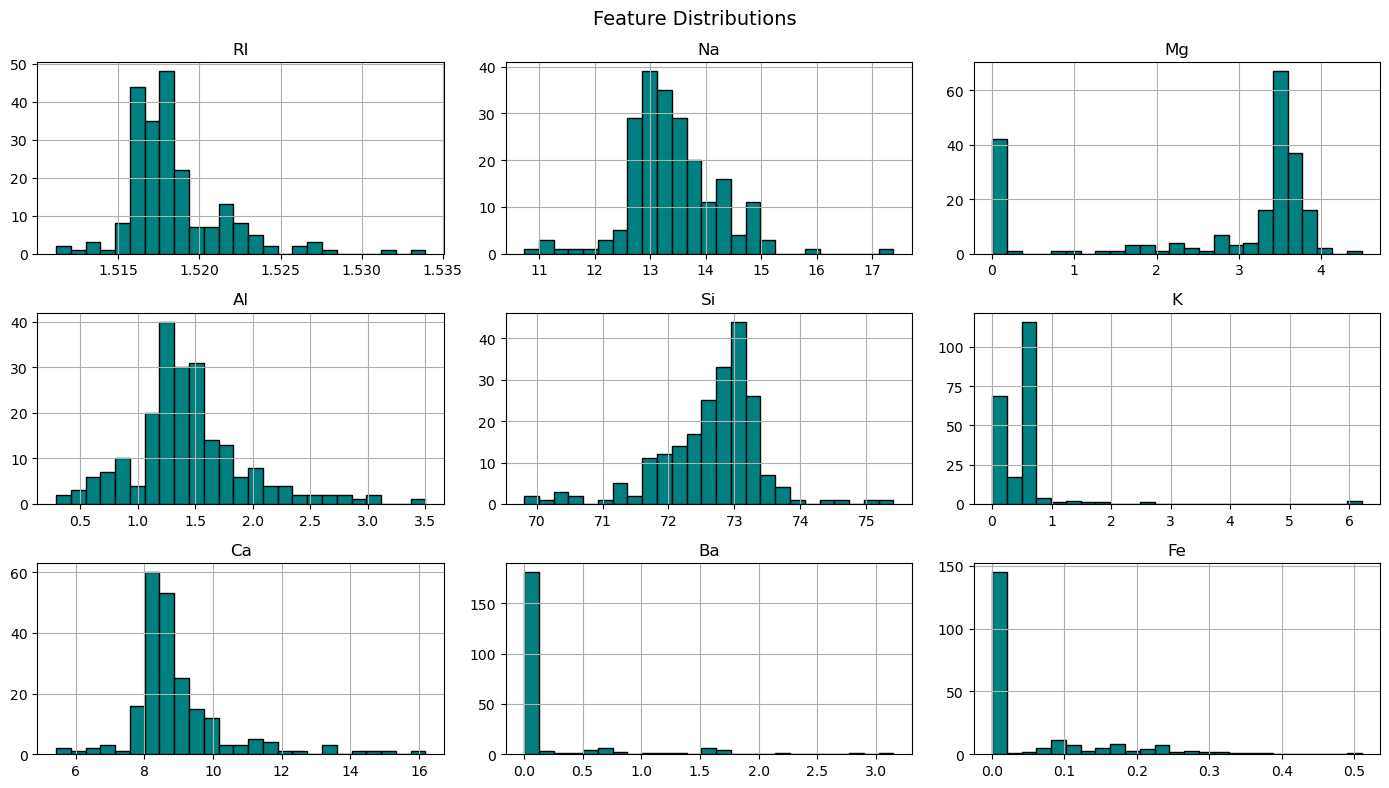

In [4]:
# ── Histograms for all features ───────────────────────────────────
features = df.columns.drop('Type')
df[features].hist(figsize=(14, 8), bins=25, color='teal', edgecolor='black')
plt.suptitle('Feature Distributions', fontsize=14)
plt.tight_layout()
plt.show()

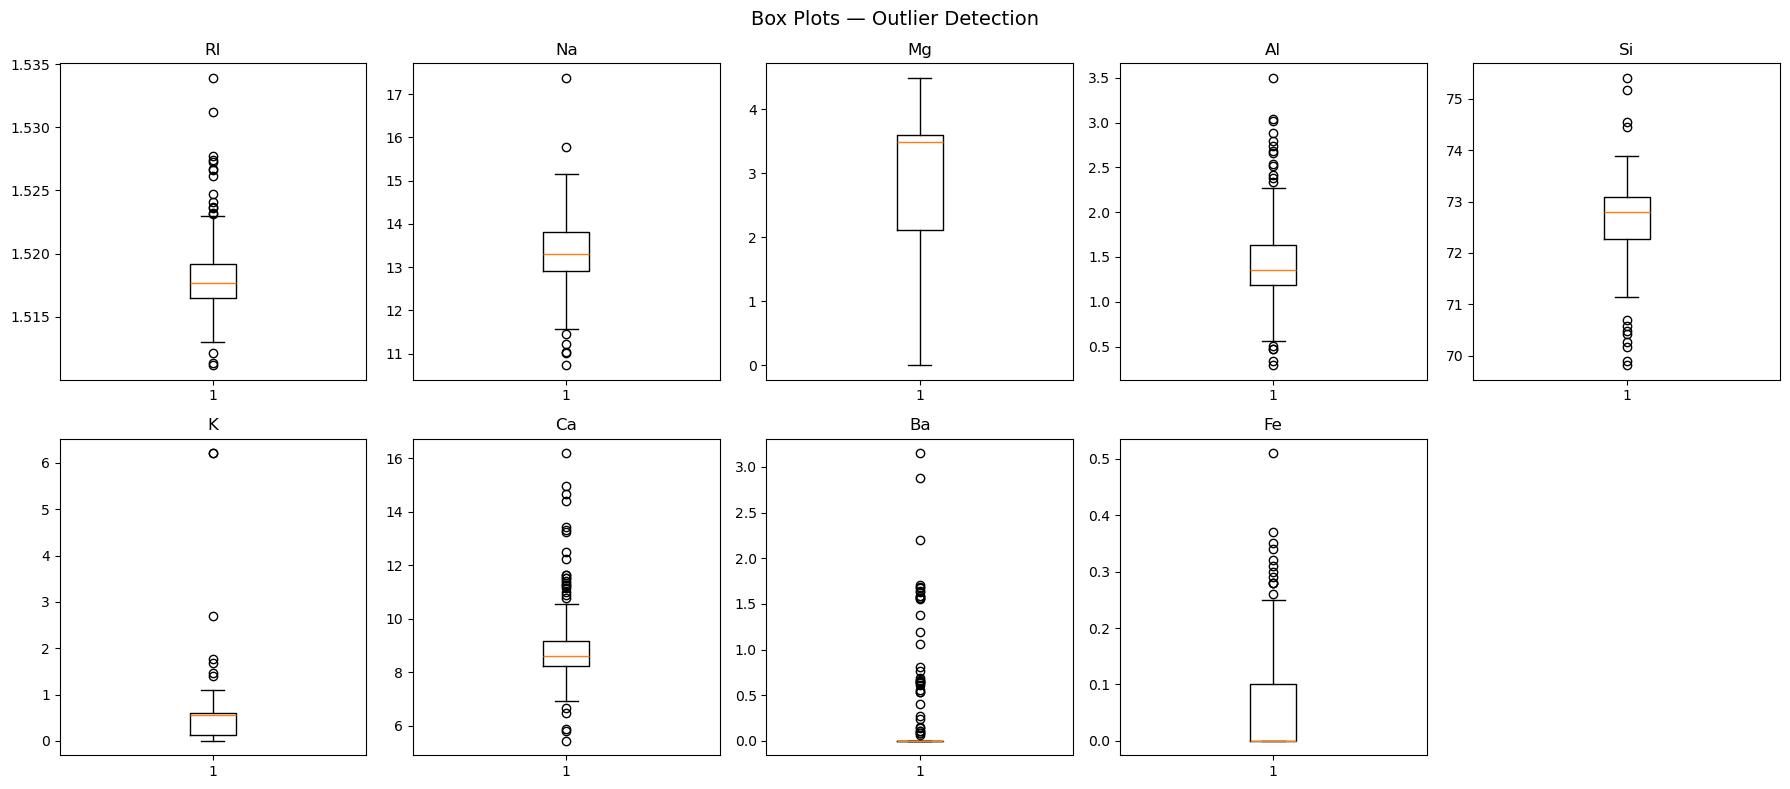

In [5]:
# ── Box plots for outlier detection ──────────────────────────────
fig, axes = plt.subplots(2, 5, figsize=(18, 8))
axes = axes.flatten()
for i, col in enumerate(features):
    axes[i].boxplot(df[col].dropna())
    axes[i].set_title(col)
axes[-1].axis('off')  # hide last empty subplot
plt.suptitle('Box Plots — Outlier Detection', fontsize=14)
plt.tight_layout()
plt.show()

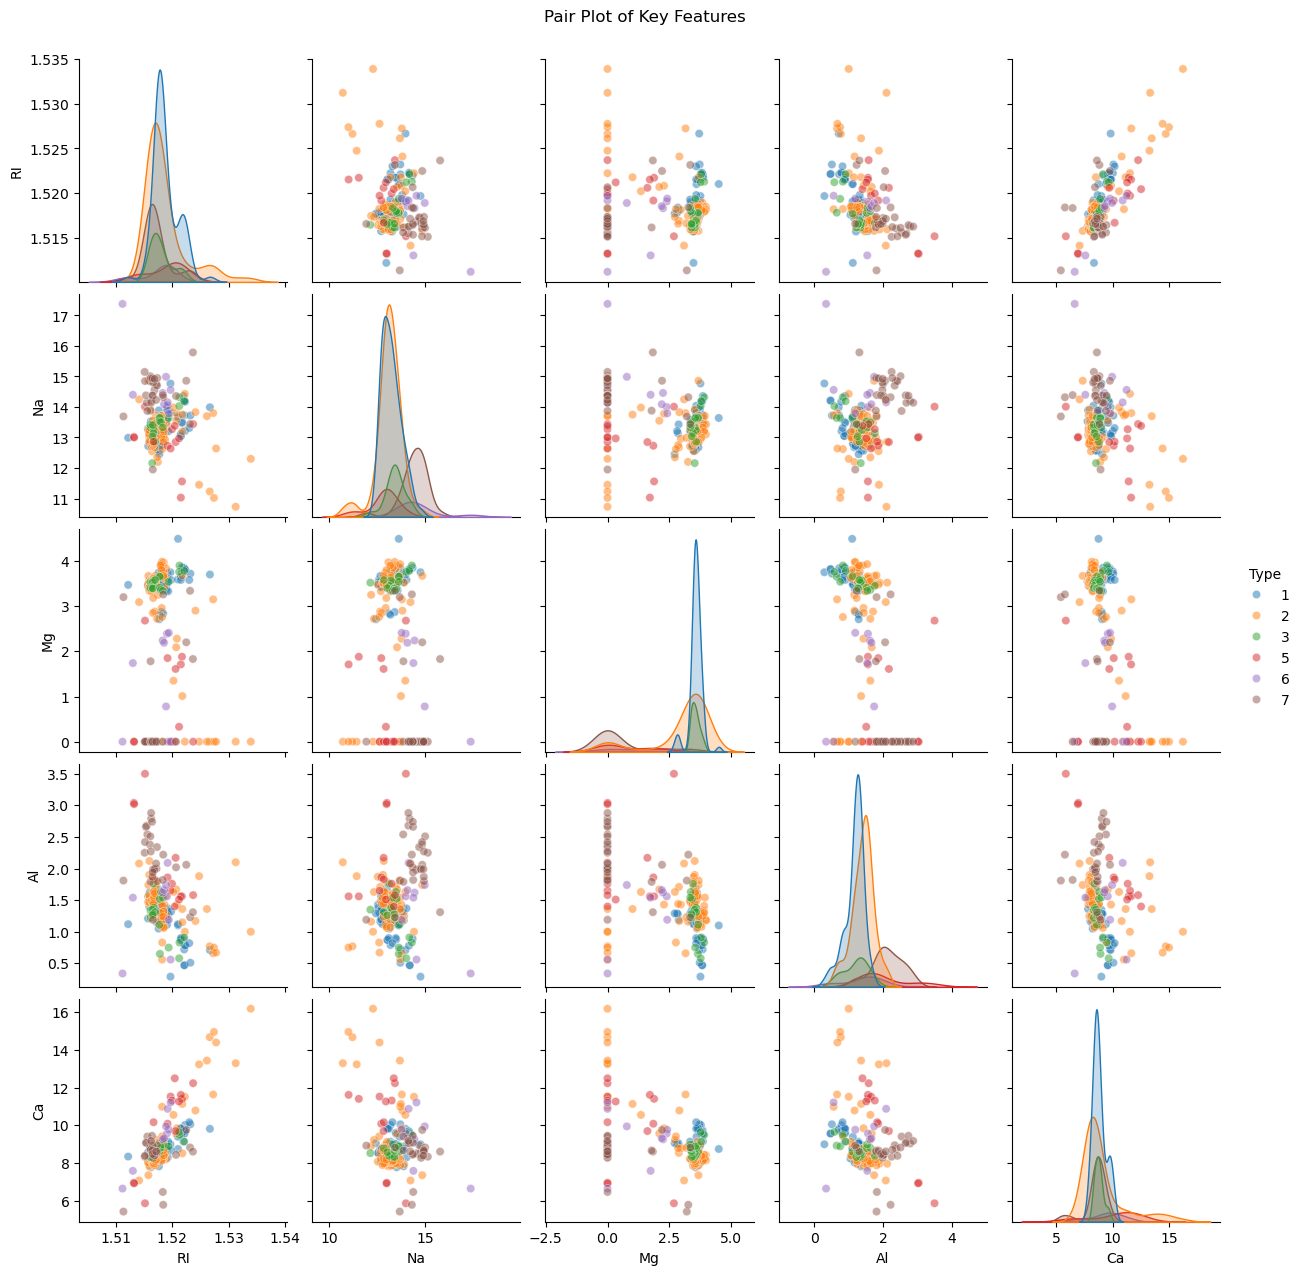

In [6]:
# ── Pair Plot ─────────────────────────────────────────────────────
sns.pairplot(df, hue='Type', vars=['RI', 'Na', 'Mg', 'Al', 'Ca'],
             palette='tab10', plot_kws={'alpha': 0.5})
plt.suptitle('Pair Plot of Key Features', y=1.02)
plt.show()

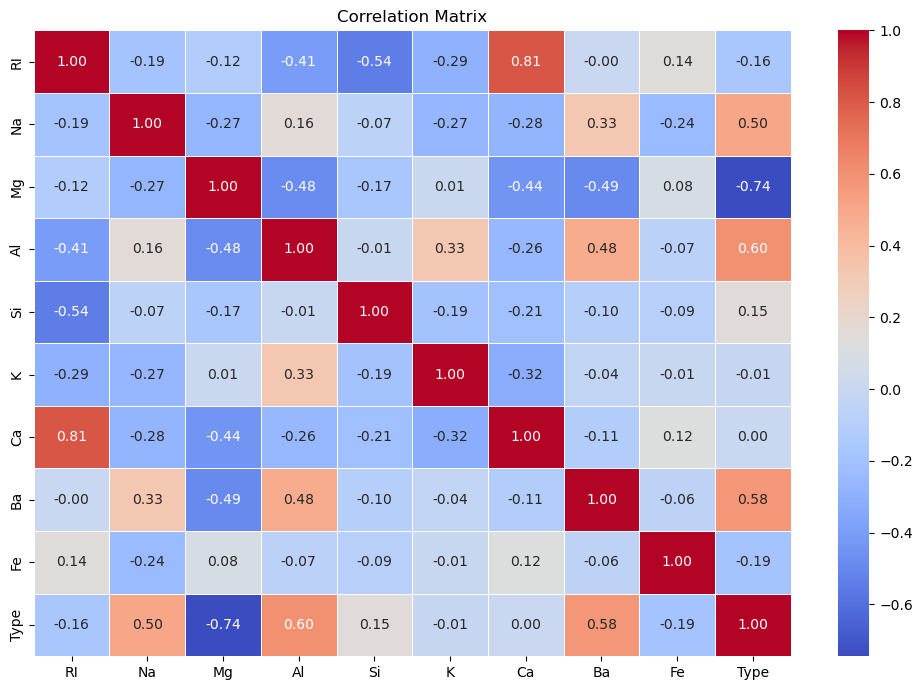

In [7]:

# ── Correlation Heatmap ───────────────────────────────────────────
plt.figure(figsize=(10, 7))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()


In [8]:
# ── 3.1 Missing Values ────────────────────────────────────────────
# No missing values in this dataset (confirmed above)
# Strategy if present: median imputation for numerical features
df_clean = df.copy()
for col in df_clean.columns:
    if df_clean[col].isnull().sum() > 0:
        df_clean[col].fillna(df_clean[col].median(), inplace=True)

# ── 3.2 No Categorical Variables ─────────────────────────────────
# All features are numerical — no encoding needed
print("All features are numeric. No encoding required.")

All features are numeric. No encoding required.


In [9]:
# ── 3.3 Feature Scaling (Standardization) ────────────────────────
from sklearn.preprocessing import StandardScaler

X = df_clean.drop(columns='Type')
y = df_clean['Type'].astype(int)

scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)
print("Scaled Features Sample:\n", X_scaled.head(3))

Scaled Features Sample:
          RI        Na        Mg        Al        Si         K        Ca  \
0  0.872868  0.284953  1.254639 -0.692442 -1.127082 -0.671705 -0.145766   
1 -0.249333  0.591817  0.636168 -0.170460  0.102319 -0.026213 -0.793734   
2 -0.721318  0.149933  0.601422  0.190912  0.438787 -0.164533 -0.828949   

         Ba        Fe  
0 -0.352877 -0.586451  
1 -0.352877 -0.586451  
2 -0.352877 -0.586451  


In [10]:
# ── 3.4 Handle Class Imbalance with SMOTE ────────────────────────
from imblearn.over_sampling import SMOTE

print("Class distribution BEFORE SMOTE:\n", y.value_counts().sort_index())

smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_scaled, y)

print("\nClass distribution AFTER SMOTE:\n",
      pd.Series(y_resampled).value_counts().sort_index())

Class distribution BEFORE SMOTE:
 Type
1    70
2    76
3    17
5    13
6     9
7    29
Name: count, dtype: int64

Class distribution AFTER SMOTE:
 Type
1    76
2    76
3    76
5    76
6    76
7    76
Name: count, dtype: int64


In [11]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, classification_report, confusion_matrix)

# ── 4.1 Train/Test Split ──────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled, test_size=0.2, random_state=42, stratify=y_resampled
)
print("Train:", X_train.shape, "| Test:", X_test.shape)

Train: (364, 9) | Test: (92, 9)


In [12]:
# ── 4.2 & 4.3 Train Random Forest ────────────────────────────────
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# ── Evaluate ──────────────────────────────────────────────────────
y_pred_rf = rf.predict(X_test)

print("=== Random Forest ===")
print(f"Accuracy  : {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Precision : {precision_score(y_test, y_pred_rf, average='weighted'):.4f}")
print(f"Recall    : {recall_score(y_test, y_pred_rf, average='weighted'):.4f}")
print(f"F1-Score  : {f1_score(y_test, y_pred_rf, average='weighted'):.4f}")
print("\nClassification Report:\n",
      classification_report(y_test, y_pred_rf))

=== Random Forest ===
Accuracy  : 0.9130
Precision : 0.9166
Recall    : 0.9130
F1-Score  : 0.9140

Classification Report:
               precision    recall  f1-score   support

           1       0.76      0.87      0.81        15
           2       0.93      0.87      0.90        15
           3       0.93      0.87      0.90        15
           5       0.94      0.94      0.94        16
           6       1.00      1.00      1.00        16
           7       0.93      0.93      0.93        15

    accuracy                           0.91        92
   macro avg       0.92      0.91      0.91        92
weighted avg       0.92      0.91      0.91        92



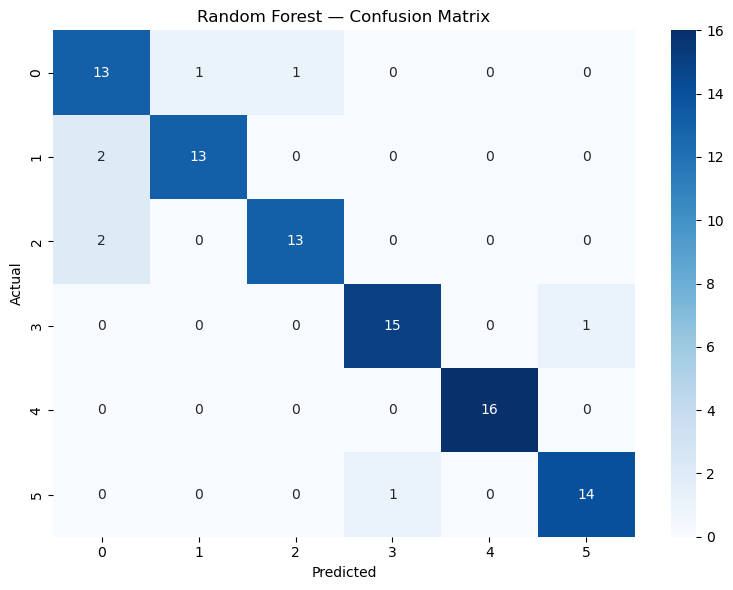

In [13]:
# Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True,
            fmt='d', cmap='Blues')
plt.title('Random Forest — Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

=== Random Forest ===
Accuracy  : 0.9130
Precision : 0.9166
Recall    : 0.9130
F1-Score  : 0.9140

Classification Report:
               precision    recall  f1-score   support

           1       0.76      0.87      0.81        15
           2       0.93      0.87      0.90        15
           3       0.93      0.87      0.90        15
           5       0.94      0.94      0.94        16
           6       1.00      1.00      1.00        16
           7       0.93      0.93      0.93        15

    accuracy                           0.91        92
   macro avg       0.92      0.91      0.91        92
weighted avg       0.92      0.91      0.91        92



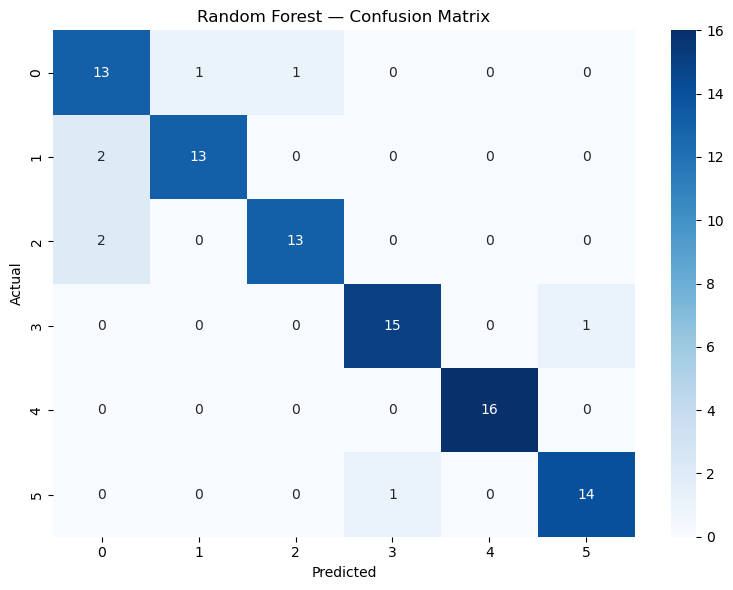

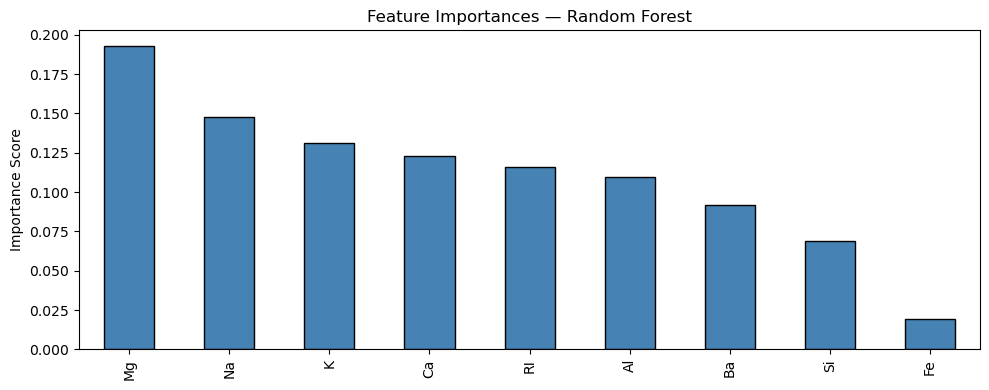

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, classification_report, confusion_matrix)
from imblearn.over_sampling import SMOTE

# ── Load & Prep ───────────────────────────────────────────────────
df = pd.read_excel("glass.xlsx", sheet_name="glass")
X = df.drop(columns='Type')
y = df['Type'].astype(int)

scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_scaled, y)

X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled, test_size=0.2, random_state=42, stratify=y_resampled
)

# ── Train Random Forest ───────────────────────────────────────────
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

# ── Metrics ───────────────────────────────────────────────────────
print("=== Random Forest ===")
print(f"Accuracy  : {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Precision : {precision_score(y_test, y_pred_rf, average='weighted'):.4f}")
print(f"Recall    : {recall_score(y_test, y_pred_rf, average='weighted'):.4f}")
print(f"F1-Score  : {f1_score(y_test, y_pred_rf, average='weighted'):.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))

# ── Confusion Matrix ──────────────────────────────────────────────
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True,
            fmt='d', cmap='Blues')
plt.title('Random Forest — Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

# ── Feature Importance ────────────────────────────────────────────
importances = pd.Series(rf.feature_importances_, index=X_scaled.columns)
importances.sort_values(ascending=False).plot(
    kind='bar', figsize=(10, 4), color='steelblue', edgecolor='black')
plt.title('Feature Importances — Random Forest')
plt.ylabel('Importance Score')
plt.tight_layout()
plt.show()

In [9]:
from sklearn.ensemble import (BaggingClassifier, AdaBoostClassifier,
                               GradientBoostingClassifier)
from sklearn.tree import DecisionTreeClassifier

# Helper function to evaluate any model
def evaluate_model(name, model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print(f"\n=== {name} ===")
    print(f"Accuracy  : {accuracy_score(y_test, y_pred):.4f}")
    print(f"Precision : {precision_score(y_test, y_pred, average='weighted'):.4f}")
    print(f"Recall    : {recall_score(y_test, y_pred, average='weighted'):.4f}")
    print(f"F1-Score  : {f1_score(y_test, y_pred, average='weighted'):.4f}")
    return {
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, average='weighted'),
        'Recall': recall_score(y_test, y_pred, average='weighted'),
        'F1': f1_score(y_test, y_pred, average='weighted')
    }

In [10]:
# ── Bagging ───────────────────────────────────────────────────────
bagging = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=100, random_state=42
)

# ── Boosting: AdaBoost ────────────────────────────────────────────
adaboost = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=3),
    n_estimators=100, random_state=42
)

# ── Boosting: Gradient Boosting ───────────────────────────────────
gboost = GradientBoostingClassifier(n_estimators=100, random_state=42)

# Run all models
results = []
results.append(evaluate_model("Random Forest",      rf,       X_train, X_test, y_train, y_test))
results.append(evaluate_model("Bagging",            bagging,  X_train, X_test, y_train, y_test))
results.append(evaluate_model("AdaBoost",           adaboost, X_train, X_test, y_train, y_test))
results.append(evaluate_model("Gradient Boosting",  gboost,   X_train, X_test, y_train, y_test))


=== Random Forest ===
Accuracy  : 0.9130
Precision : 0.9166
Recall    : 0.9130
F1-Score  : 0.9140

=== Bagging ===
Accuracy  : 0.8913
Precision : 0.8913
Recall    : 0.8913
F1-Score  : 0.8904


C:\Users\akshara\software_tools\conda\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(



=== AdaBoost ===
Accuracy  : 0.8261
Precision : 0.8342
Recall    : 0.8261
F1-Score  : 0.8233

=== Gradient Boosting ===
Accuracy  : 0.9130
Precision : 0.9167
Recall    : 0.9130
F1-Score  : 0.9136


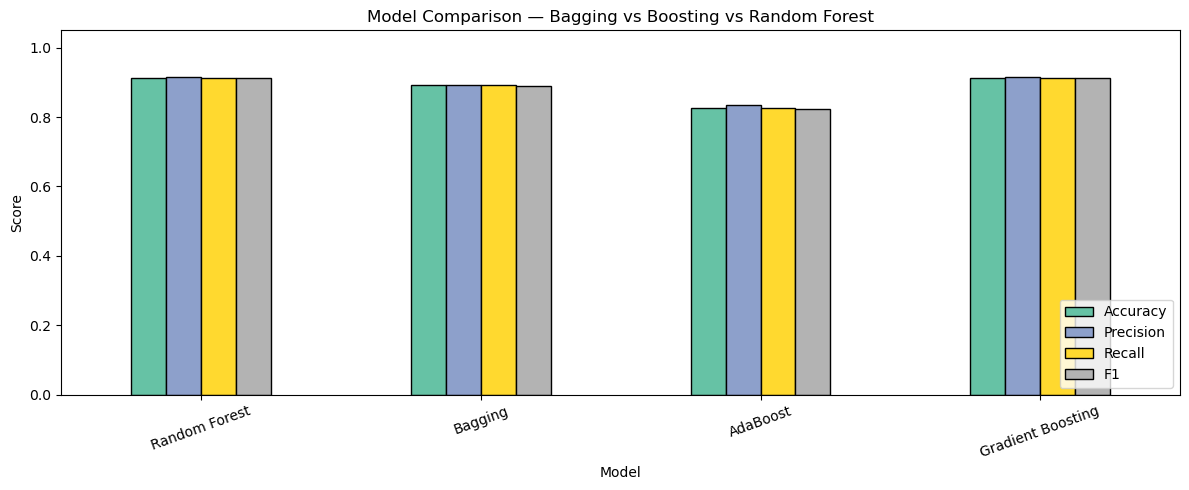


Full Comparison Table:
             Model  Accuracy  Precision  Recall     F1
    Random Forest    0.9130     0.9166  0.9130 0.9140
          Bagging    0.8913     0.8913  0.8913 0.8904
         AdaBoost    0.8261     0.8342  0.8261 0.8233
Gradient Boosting    0.9130     0.9167  0.9130 0.9136


In [11]:
# ── Comparison Chart ──────────────────────────────────────────────
results_df = pd.DataFrame(results)
results_df.set_index('Model')[['Accuracy', 'Precision', 'Recall', 'F1']].plot(
    kind='bar', figsize=(12, 5), edgecolor='black', colormap='Set2')
plt.title('Model Comparison — Bagging vs Boosting vs Random Forest')
plt.ylabel('Score')
plt.xticks(rotation=20)
plt.ylim(0, 1.05)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

print("\nFull Comparison Table:\n", results_df.round(4).to_string(index=False))